# F1 Pit Stop Prediction - Baseline Model

**Kaggle Playground Series S6E5**

LightGBM with all 38 engineered features and GroupKFold CV by race. Goal is a clean first submission on the leaderboard and a solid OOF AUC to build from.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110
SEED = 42

## 1. Load and Engineer Features

We copy the feature engineering pipeline from notebook 03 directly here so the model notebook is self-contained.

In [2]:
train_raw = pd.read_csv('../data/train.csv')
test_raw  = pd.read_csv('../data/test.csv')
sub       = pd.read_csv('../data/sample_submission.csv')

sort_keys = ['Race', 'Year', 'Driver', 'LapNumber']
train_raw = train_raw.sort_values(sort_keys).reset_index(drop=True)
test_raw  = test_raw.sort_values(sort_keys).reset_index(drop=True)

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')

Train: (439140, 16)  |  Test: (188165, 15)


In [3]:
def add_tier1_features(df, compound_stats=None, is_train=True):
    df = df.copy()
    if is_train:
        compound_stats = df[df['PitNextLap'] == 1].groupby('Compound')['TyreLife'].agg(
            compound_pit_median='median',
            compound_pit_std='std'
        ).reset_index()
    df = df.merge(compound_stats, on='Compound', how='left')
    df['TyreLife_vs_PitWindow'] = df['TyreLife'] - df['compound_pit_median']
    df['TyreLife_PitWindow_Z']  = df['TyreLife_vs_PitWindow'] / (df['compound_pit_std'] + 1)
    df['In_PitWindow']          = (df['TyreLife'] >= df['compound_pit_median'] * 0.75).astype(int)
    df['Deg_Rate']              = df['Cumulative_Degradation'] / (df['TyreLife'] + 1)
    df['LapsRemaining']         = 1.0 - df['RaceProgress']
    df['Already_Pitted']        = (df['Stint'] > 1).astype(int)
    df['Early_Race']            = (df['RaceProgress'] < 0.12).astype(int)
    df['Late_Race']             = (df['RaceProgress'] > 0.92).astype(int)
    df['Mid_Race']              = ((df['RaceProgress'] >= 0.25) & (df['RaceProgress'] <= 0.75)).astype(int)
    df['Position_x_TyreLife']   = df['Position'] * df['TyreLife']
    df['TyreLife_norm']         = df['TyreLife'] / df['compound_pit_median']
    return df, compound_stats


def add_tier2_features(df):
    df = df.copy()
    group = ['Race', 'Year', 'Driver']
    df['LapTime_Roll3']    = df.groupby(group)['LapTime (s)'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['LapTime_Roll5']    = df.groupby(group)['LapTime (s)'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    df['LapTime_Trend3']   = df['LapTime (s)'] - df['LapTime_Roll3']
    df['LapTime_Trend5']   = df['LapTime (s)'] - df['LapTime_Roll5']
    df['LapTime_vs_Median']= df.groupby(group)['LapTime (s)'].transform(lambda x: x - x.median())
    df['Deg_Roll3']        = df.groupby(group)['Cumulative_Degradation'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['Deg_Trend']        = df['Cumulative_Degradation'] - df['Deg_Roll3']
    df['PitStop_Lag1']     = df.groupby(group)['PitStop'].shift(1).fillna(0)
    df['TyreLife_Lag1']    = df.groupby(group)['TyreLife'].shift(1).fillna(0)
    df['LapTime_Lag1']     = df.groupby(group)['LapTime (s)'].shift(1).fillna(df['LapTime (s)'])
    df['Laps_Since_Pit']   = df.groupby(group)['PitStop'].transform(
        lambda x: x.groupby((x != x.shift()).cumsum()).cumcount())
    df['PosCh_Roll3']      = df.groupby(group)['Position_Change'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    return df


def add_tier3_features(train_df, test_df):
    train_df = train_df.copy()
    test_df  = test_df.copy()
    compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
    train_df['Compound_enc'] = train_df['Compound'].map(compound_map).fillna(1)
    test_df['Compound_enc']  = test_df['Compound'].map(compound_map).fillna(1)
    te = TargetEncoder(target_type='binary', smooth='auto', random_state=SEED)
    train_df['Driver_enc'] = te.fit_transform(train_df[['Driver']], train_df['PitNextLap']).ravel()
    test_df['Driver_enc']  = te.transform(test_df[['Driver']]).ravel()
    te2 = TargetEncoder(target_type='binary', smooth='auto', random_state=SEED)
    train_df['Race_enc'] = te2.fit_transform(train_df[['Race']], train_df['PitNextLap']).ravel()
    test_df['Race_enc']  = te2.transform(test_df[['Race']]).ravel()
    dc_rate = (train_df.groupby(['Driver', 'Compound'])['PitNextLap'].mean()
               .reset_index().rename(columns={'PitNextLap': 'Driver_Compound_PitRate'}))
    train_df = train_df.merge(dc_rate, on=['Driver', 'Compound'], how='left')
    test_df  = test_df.merge(dc_rate,  on=['Driver', 'Compound'], how='left')
    test_df['Driver_Compound_PitRate'] = test_df['Driver_Compound_PitRate'].fillna(
        train_df['Driver_Compound_PitRate'].mean())
    return train_df, test_df


train, compound_stats = add_tier1_features(train_raw, is_train=True)
test,  _              = add_tier1_features(test_raw, compound_stats=compound_stats, is_train=False)
train = add_tier2_features(train)
test  = add_tier2_features(test)
train, test = add_tier3_features(train, test)

print('Feature engineering done.')

Feature engineering done.


In [4]:
raw_features   = ['LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
                  'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress',
                  'Position_Change', 'PitStop', 'Year']
tier1_features = ['TyreLife_vs_PitWindow', 'TyreLife_PitWindow_Z', 'In_PitWindow',
                  'Deg_Rate', 'LapsRemaining', 'Already_Pitted', 'Early_Race',
                  'Late_Race', 'Mid_Race', 'Position_x_TyreLife', 'TyreLife_norm']
tier2_features = ['LapTime_Roll3', 'LapTime_Roll5', 'LapTime_Trend3', 'LapTime_Trend5',
                  'LapTime_vs_Median', 'Deg_Roll3', 'Deg_Trend', 'PitStop_Lag1',
                  'TyreLife_Lag1', 'LapTime_Lag1', 'Laps_Since_Pit', 'PosCh_Roll3']
tier3_features = ['Compound_enc', 'Driver_enc', 'Race_enc', 'Driver_Compound_PitRate']

FEATURES = raw_features + tier1_features + tier2_features + tier3_features

X      = train[FEATURES]
y      = train['PitNextLap']
X_test = test[FEATURES]
groups = train['Race'] + '_' + train['Year'].astype(str)

print(f'Features: {len(FEATURES)}  |  Train: {X.shape}  |  Test: {X_test.shape}')

Features: 38  |  Train: (439140, 38)  |  Test: (188165, 38)


## 2. LightGBM with GroupKFold CV

In [5]:
lgb_params = {
    'objective':        'binary',
    'metric':           'auc',
    'n_estimators':     3000,
    'learning_rate':    0.05,
    'num_leaves':       127,
    'min_child_samples':50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     1,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'scale_pos_weight': 4,
    'verbose':          -1,
    'random_state':     SEED,
}

gkf        = GroupKFold(n_splits=5)
oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_aucs  = []
models     = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr,  X_val  = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val  = y.iloc[tr_idx],  y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(500)
        ]
    )

    oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_preds         += model.predict_proba(X_test)[:, 1] / 5
    models.append(model)

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f'Fold {fold+1}  |  AUC: {fold_auc:.5f}  |  Trees: {model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\nOOF AUC: {oof_auc:.5f}')
print(f'Folds:   {[round(a, 5) for a in fold_aucs]}')

[500]	valid_0's auc: 0.927162
Fold 1  |  AUC: 0.92789  |  Trees: 698
Fold 2  |  AUC: 0.92961  |  Trees: 349
[500]	valid_0's auc: 0.942602
Fold 3  |  AUC: 0.94266  |  Trees: 420
Fold 4  |  AUC: 0.93406  |  Trees: 342
Fold 5  |  AUC: 0.92219  |  Trees: 256

OOF AUC: 0.93169
Folds:   [0.92789, 0.92961, 0.94266, 0.93406, 0.92219]


## 3. OOF Analysis

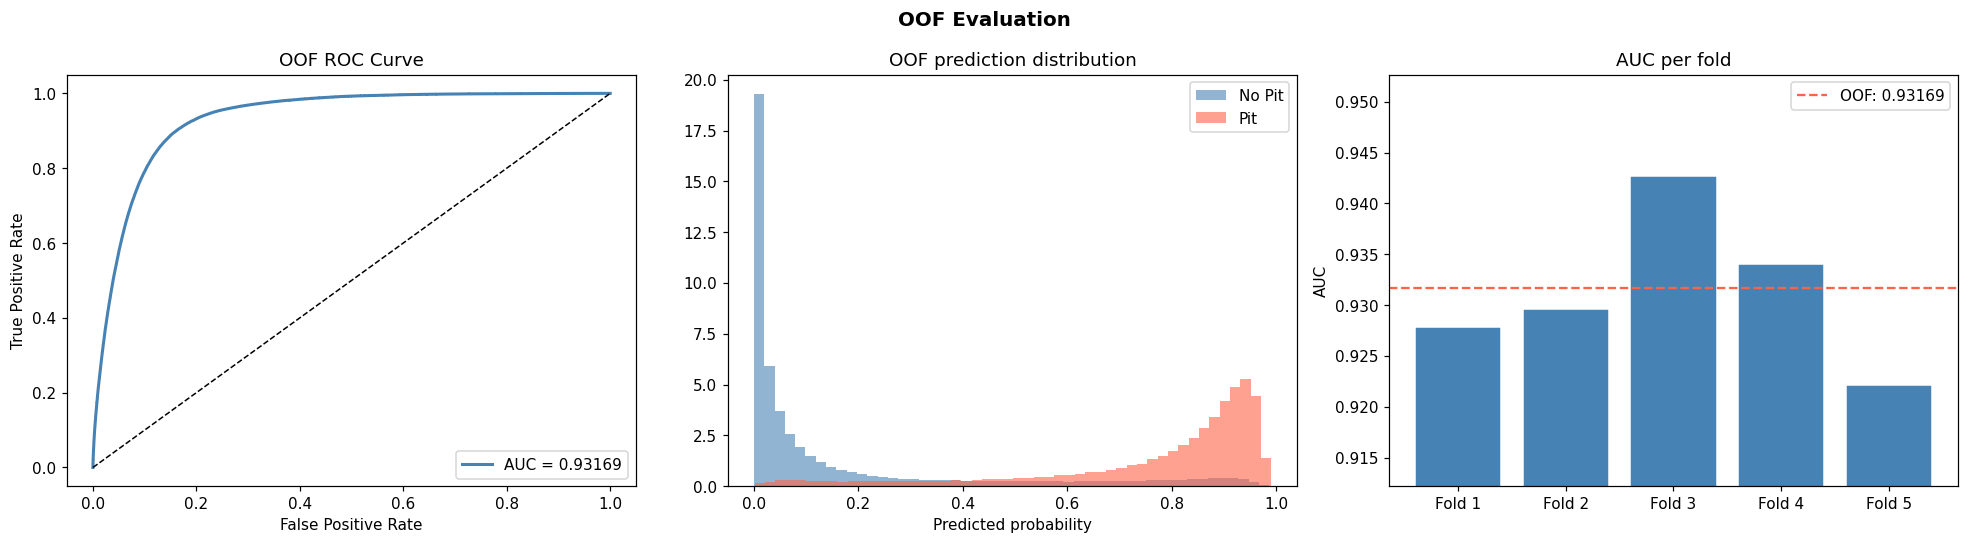

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve
fpr, tpr, thresholds = roc_curve(y, oof_preds)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {oof_auc:.5f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('OOF ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# OOF prediction distribution
axes[1].hist(oof_preds[y==0], bins=50, alpha=0.6, color='steelblue', label='No Pit', density=True)
axes[1].hist(oof_preds[y==1], bins=50, alpha=0.6, color='tomato',    label='Pit',    density=True)
axes[1].set_title('OOF prediction distribution')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

# Fold AUC bar chart
axes[2].bar([f'Fold {i+1}' for i in range(5)], fold_aucs, color='steelblue', edgecolor='white')
axes[2].axhline(oof_auc, color='tomato', linestyle='--', linewidth=1.5, label=f'OOF: {oof_auc:.5f}')
axes[2].set_title('AUC per fold')
axes[2].set_ylabel('AUC')
axes[2].set_ylim(min(fold_aucs) - 0.01, max(fold_aucs) + 0.01)
axes[2].legend()

plt.suptitle('OOF Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Importance

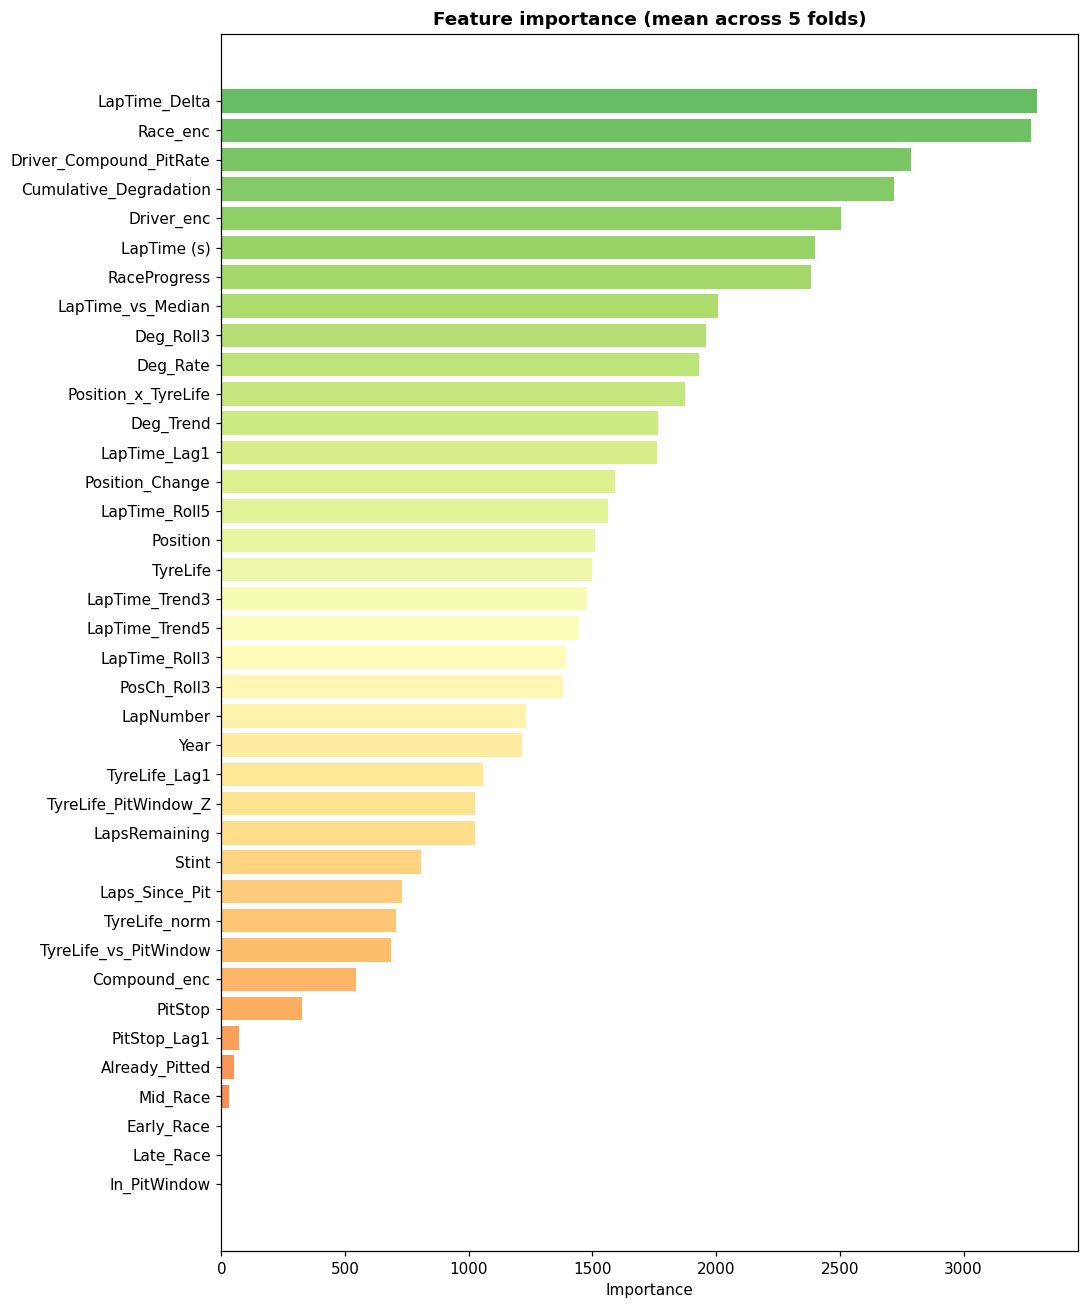

Top 10 features:
                feature  importance
          LapTime_Delta      3297.8
               Race_enc      3273.8
Driver_Compound_PitRate      2787.6
 Cumulative_Degradation      2720.2
             Driver_enc      2504.4
            LapTime (s)      2398.8
           RaceProgress      2382.2
      LapTime_vs_Median      2007.2
              Deg_Roll3      1957.8
               Deg_Rate      1930.4


In [7]:
# Average importance across all folds
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df))[::-1])
ax.barh(importance_df['feature'], importance_df['importance'], color=colors, edgecolor='none')
ax.invert_yaxis()
ax.set_title('Feature importance (mean across 5 folds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

## 5. Optimal Threshold

In [8]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)
optimal_idx       = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print(f'Optimal threshold (Youden): {optimal_threshold:.4f}')
print(f'TPR at threshold:           {tpr[optimal_idx]:.4f}')
print(f'FPR at threshold:           {fpr[optimal_idx]:.4f}')

Optimal threshold (Youden): 0.3894
TPR at threshold:           0.9035
FPR at threshold:           0.1643


## 6. Create Submission

In [ ]:
import os
os.makedirs('../submissions', exist_ok=True)

sub = pd.read_csv('../data/sample_submission.csv')
sub['PitNextLap'] = 0.0

test_sorted = test.sort_values('id').reset_index(drop=True)
sub_sorted  = sub.sort_values('id').reset_index(drop=True)
sub_sorted['PitNextLap'] = test_preds[test.sort_values('id').index]

sub_sorted.to_csv('../submissions/submission_lgb_baseline.csv', index=False)

print(f'Submission saved: submission_lgb_baseline.csv')
print(f'OOF AUC: {oof_auc:.5f}')
print(f'Prediction range: {test_preds.min():.4f} to {test_preds.max():.4f}')
print(f'Mean prediction:  {test_preds.mean():.4f}')
sub_sorted.head()

## 7. Score Log

Update `submissions/score_log.md` with OOF AUC after uploading to Kaggle.

| Submission | OOF AUC | LB AUC | Notes |
|---|---|---|---|
| submission_lgb_baseline.csv | ? | ? | Fill in after submitting |